In [10]:
from google.colab import files
uploaded = files.upload()

Saving e2644dea-8b57-43dc-a559-71202c68faf1.png to e2644dea-8b57-43dc-a559-71202c68faf1.png
Saving Van_Gogh_-_Starry_Night_-_Google_Art_Project.jpg.webp to Van_Gogh_-_Starry_Night_-_Google_Art_Project.jpg.webp


In [24]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.models as models
from PIL import Image
import matplotlib.pyplot as plt
import os

In [25]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [28]:
image_size = 512 if torch.cuda.is_available() else 256

loader = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

def load_image(image_path):
    image = Image.open(image_path).convert("RGB")
    image = loader(image).unsqueeze(0)
    return image.to(device, torch.float)

content_image = load_image("content.png")
style_image = load_image("style.jpg")

In [29]:
def imshow(tensor, title=None):
    image = tensor.clone().detach().cpu().squeeze(0)

    # De-normalize
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)

    image = image * std + mean
    image = torch.clamp(image, 0, 1)

    image = transforms.ToPILImage()(image)

    plt.imshow(image)
    if title:
        plt.title(title)
    plt.axis("off")


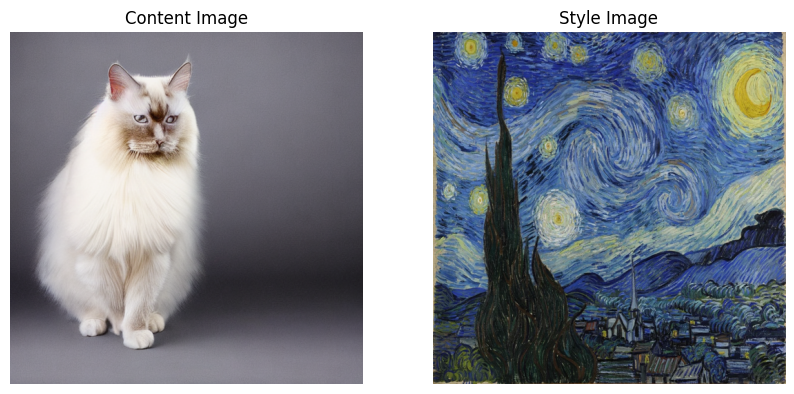

In [30]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
imshow(content_image, "Content Image")

plt.subplot(1,2,2)
imshow(style_image, "Style Image")

plt.show()

In [31]:
vgg = models.vgg19(pretrained=True).features.to(device).eval()

for param in vgg.parameters():
    param.requires_grad = False

In [32]:
def get_features(image, model):
    layers = {
        '0': 'conv_1',
        '5': 'conv_2',
        '10': 'conv_3',
        '19': 'conv_4',
        '28': 'conv_5'
    }

    features = {}
    x = image

    for name, layer in model._modules.items():
        x = layer(x)
        if name in layers:
            features[layers[name]] = x

    return features

content_features = get_features(content_image, vgg)
style_features = get_features(style_image, vgg)

In [33]:

def gram_matrix(tensor):
    _, d, h, w = tensor.size()
    tensor = tensor.view(d, h*w)
    gram = torch.mm(tensor, tensor.t())
    return gram

In [34]:
target = content_image.clone().requires_grad_(True).to(device)

In [35]:
optimizer = optim.LBFGS([target])

content_layer = 'conv_4'

style_layers = ['conv_1', 'conv_2', 'conv_3', 'conv_4', 'conv_5']

style_weights = {
    'conv_1': 1.0,
    'conv_2': 0.8,
    'conv_3': 0.5,
    'conv_4': 0.3,
    'conv_5': 0.1
}

content_weight = 5e3
style_weight = 2e5

In [36]:
output_dir = "nst_outputs"
os.makedirs(output_dir, exist_ok=True)

print("Folder created:", output_dir)


Folder created: nst_outputs


In [38]:

steps = 2000
run = [0]

while run[0] <= steps:

    def closure():
        optimizer.zero_grad()

        target_features = get_features(target, vgg)

        content_loss = torch.mean(
            (target_features[content_layer] - content_features[content_layer])**2
        )

        style_loss = 0
        for layer in style_layers:
            target_feature = target_features[layer]
            target_gram = gram_matrix(target_feature)

            style_feature = style_features[layer]
            style_gram = gram_matrix(style_feature)

            _, d, h, w = target_feature.shape

            layer_style_loss = style_weights[layer] * torch.mean(
                (target_gram - style_gram)**2
            ) / (d*h*w)

            style_loss += layer_style_loss

        total_loss = content_weight * content_loss + style_weight * style_loss

        total_loss.backward()


        if run[0] % 100 == 0:
            print(f"Step {run[0]}, Total Loss: {total_loss.item()}")
            temp = target.clone().detach().cpu().squeeze(0)
            mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
            std = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
            temp = temp * std + mean
            temp = torch.clamp(temp, 0, 1)

            temp_img = transforms.ToPILImage()(temp)
            temp_img.save(os.path.join(output_dir, f"output_step_{run[0]}.jpg"))

        run[0] += 1
        return total_loss

    optimizer.step(closure)

    with torch.no_grad():
        target.clamp_(-3, 3)

Step 0, Total Loss: 61760.859375
Step 100, Total Loss: 61641.25
Step 200, Total Loss: 61537.62109375
Step 300, Total Loss: 61443.99609375
Step 400, Total Loss: 61357.33203125
Step 500, Total Loss: 61282.32421875
Step 600, Total Loss: 61211.5546875
Step 700, Total Loss: 61145.6484375
Step 800, Total Loss: 61084.38671875
Step 900, Total Loss: 61027.36328125
Step 1000, Total Loss: 60975.3515625
Step 1100, Total Loss: 60926.9375
Step 1200, Total Loss: 60881.99609375
Step 1300, Total Loss: 60840.4453125
Step 1400, Total Loss: 60801.9375
Step 1500, Total Loss: 60766.1640625
Step 1600, Total Loss: 60732.20703125
Step 1700, Total Loss: 60700.85546875
Step 1800, Total Loss: 60671.42578125
Step 1900, Total Loss: 60643.58203125
Step 2000, Total Loss: 60617.51953125


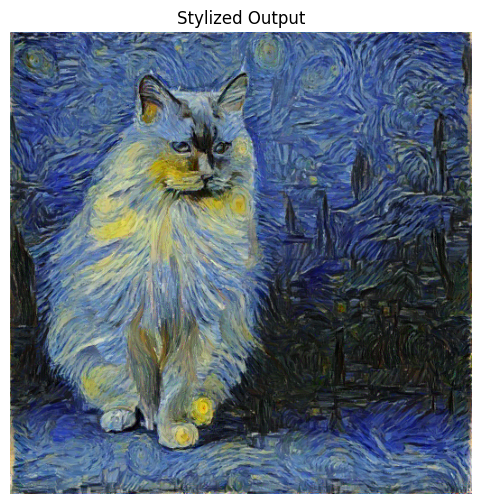

In [39]:
plt.figure(figsize=(6,6))
imshow(target, "Stylized Output")
plt.show()